# Phase 2 Project — Machine Learning Model Development


**Prepared by:** Madawi Alshebil  
**Email:** Madawi.alshebil@gmail.com  
**Supervisor:** Dr. Safwan Al-Selwi  
**Email:** saf1.alselwi@gmail.com

This project develops three end-to-end Scikit-learn pipelines:

1. **Regression:** Diabetes disease-progression prediction  
2. **Binary classification:** Breast-cancer malignancy prediction  
3. **Clustering:** Iris flower grouping using K-Means  

The notebook covers data inspection, preprocessing, EDA, model comparison,
evaluation, and final model selection.




## 1. Imports and configuration

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.datasets import load_diabetes, load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

## 2. Helper functions

These functions reduce repeated code and keep the notebook organized.


In [ ]:
def iqr_outlier_counts(dataframe):
    """Return the number of IQR outliers in every numerical column."""
    counts = {}
    for column in dataframe.select_dtypes(include=np.number).columns:
        q1 = dataframe[column].quantile(0.25)
        q3 = dataframe[column].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        counts[column] = int(
            ((dataframe[column] < lower) | (dataframe[column] > upper)).sum()
        )
    return pd.Series(counts, name="IQR Outlier Count").sort_values(ascending=False)


def regression_metrics(y_true, y_pred):
    """Calculate the main regression evaluation metrics."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


def classification_metrics(y_true, y_pred, y_score):
    """Calculate binary-classification metrics for the positive class."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_score)
    }


def get_positive_scores(model, X):
    """Return positive-class scores for ROC-AUC and ROC curves."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)


def plot_confusion_matrix(cm, class_names, title):
    """Display a confusion matrix using Matplotlib only."""
    fig, ax = plt.subplots(figsize=(5, 4))
    image = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    fig.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.show()


# Part A — Regression Pipeline

## 3. Load the Diabetes dataset

The target is a continuous measure of disease progression one year after baseline, so this is a regression task.


In [ ]:
diabetes = load_diabetes(as_frame=True)

X_reg = diabetes.data.copy()
y_reg = diabetes.target.copy()
regression_df = X_reg.copy()
regression_df["target"] = y_reg

print("Dataset shape:", regression_df.shape)
print("\nFirst five rows:")
display(regression_df.head())

print("\nFeature names:")
print(list(X_reg.columns))

print("\nTarget description:")
display(y_reg.describe().to_frame("target"))


Dataset shape: (442, 11)

First five rows:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.0381,0.0507,0.0617,0.0219,-0.0442,-0.0348,-0.0434,-0.0026,0.0199,-0.0176,151.0000
1,-0.0019,-0.0446,-0.0515,-0.0263,-0.0084,-0.0192,0.0744,-0.0395,-0.0683,-0.0922,75.0000
2,0.0853,0.0507,0.0445,-0.0057,-0.0456,-0.0342,-0.0324,-0.0026,0.0029,-0.0259,141.0000
3,-0.0891,-0.0446,-0.0116,-0.0367,0.0122,0.0250,-0.0360,0.0343,0.0227,-0.0094,206.0000
4,0.0054,-0.0446,-0.0364,0.0219,0.0039,0.0156,0.0081,-0.0026,-0.0320,-0.0466,135.0000



Feature names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Target description:


,target
count,442.0000
mean,152.1335
std,77.0930
min,25.0000
25%,87.0000
50%,140.5000
75%,211.5000
max,346.0000


## 4. Regression data-quality checks and EDA

In [ ]:
print("Missing values:")
display(regression_df.isnull().sum().to_frame("Missing Values"))

print("Number of duplicate rows:", regression_df.duplicated().sum())

print("\nIQR outlier counts:")
display(iqr_outlier_counts(regression_df).to_frame())

print(
    "\nDecision: The dataset has no missing values. "
    "Potential outliers are retained because they may represent valid patients, "
    "and tree-based models are also included in the comparison."
)


Missing values:


,Missing Values
age,0
sex,0
bmi,0
bp,0
s1,0
s2,0
s3,0
s4,0
s5,0
s6,0


Number of duplicate rows: 0

IQR outlier counts:


,IQR Outlier Count
s6,9
s1,8
s3,7
s2,7
s5,4
bmi,3
s4,2
sex,0
age,0
bp,0



Decision: The dataset has no missing values. Potential outliers are retained because they may represent valid patients, and tree-based models are also included in the comparison.


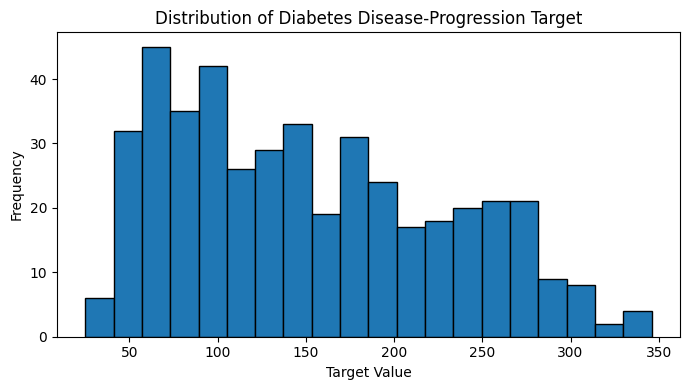

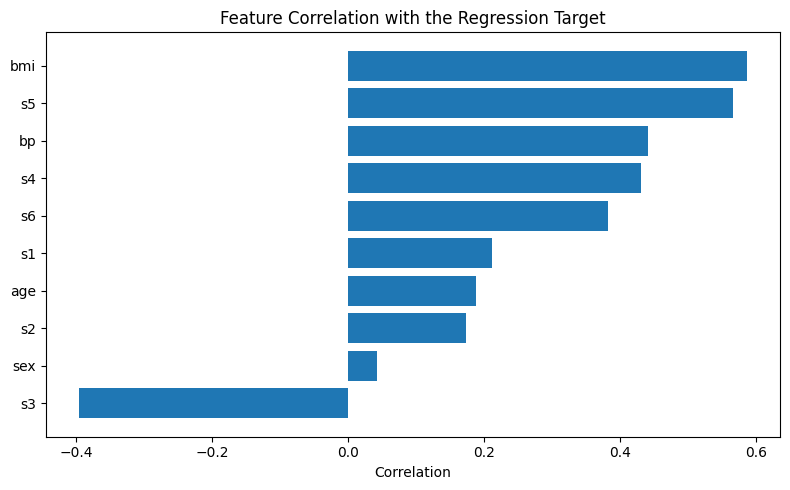

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(y_reg, bins=20, edgecolor="black")
plt.title("Distribution of Diabetes Disease-Progression Target")
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

correlations = regression_df.corr(numeric_only=True)["target"].drop("target")
correlations = correlations.sort_values()

plt.figure(figsize=(8, 5))
plt.barh(correlations.index, correlations.values)
plt.title("Feature Correlation with the Regression Target")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()


## 5. Train, validation, and test split

The data is divided into:

- **60% training:** fit the candidate models;
- **20% validation:** compare and select the best model;
- **20% testing:** report the final unbiased performance.


In [ ]:
X_reg_train_full, X_reg_test, y_reg_train_full, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE
)

X_reg_train, X_reg_val, y_reg_train, y_reg_val = train_test_split(
    X_reg_train_full,
    y_reg_train_full,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_reg_train))
print("Validation samples:", len(X_reg_val))
print("Test samples:", len(X_reg_test))


Training samples: 264
Validation samples: 89
Test samples: 89


## 6. Regression model comparison

Scaling is included inside pipelines for Linear Regression, SVR, and KNN.  
Decision Tree and Random Forest are not scaled because tree models do not depend on feature distance.


In [ ]:
regression_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        min_samples_leaf=5,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Support Vector Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(C=10, kernel="rbf", epsilon=0.1))
    ]),
    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(
            n_neighbors=7,
            weights="distance"
        ))
    ])
}

regression_rows = []

for model_name, model in regression_models.items():
    fitted_model = clone(model)
    fitted_model.fit(X_reg_train, y_reg_train)
    train_predictions = fitted_model.predict(X_reg_train)
    validation_predictions = fitted_model.predict(X_reg_val)

    train_results = regression_metrics(y_reg_train, train_predictions)
    validation_results = regression_metrics(y_reg_val, validation_predictions)

    regression_rows.append({
        "Model": model_name,
        "Train_RMSE": train_results["RMSE"],
        "Validation_MAE": validation_results["MAE"],
        "Validation_RMSE": validation_results["RMSE"],
        "Validation_R2": validation_results["R2"],
        "RMSE_Gap": validation_results["RMSE"] - train_results["RMSE"]
    })


regression_results = (
    pd.DataFrame(regression_rows)
    .sort_values("Validation_RMSE")
    .reset_index(drop=True)
)

display(regression_results)


,Model,Train_RMSE,Validation_MAE,Validation_RMSE,Validation_R2,RMSE_Gap
0,Linear Regression,54.6104,42.9389,51.1937,0.5216,-3.4166
1,Random Forest,26.7856,44.0253,54.0770,0.4662,27.2914
2,Support Vector Regression,56.1156,47.8549,56.4975,0.4174,0.3819
3,K-Nearest Neighbors,0.0000,45.4159,56.8163,0.4108,56.8163
4,Decision Tree,42.6060,50.8850,63.3426,0.2677,20.7365


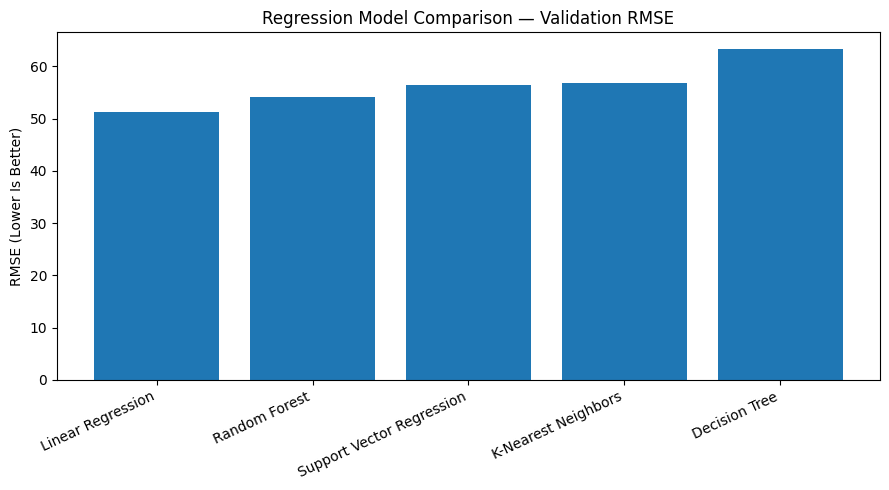

The Train_RMSE, Validation_RMSE, and RMSE_Gap columns in the table are used to check possible overfitting and generalization.


In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(
    regression_results["Model"],
    regression_results["Validation_RMSE"]
)
plt.title("Regression Model Comparison — Validation RMSE")
plt.ylabel("RMSE (Lower Is Better)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

print(
    "The Train_RMSE, Validation_RMSE, and RMSE_Gap columns in the table "
    "are used to check possible overfitting and generalization."
)


## 7. Select and test the best regression model

The selected model is the one with the **lowest validation RMSE**.  
It is retrained using the combined training and validation data, then evaluated once on the untouched test set.


Selected regression model: Linear Regression

Final test metrics:


,MAE,RMSE,R2
0,42.7941,53.8534,0.4526


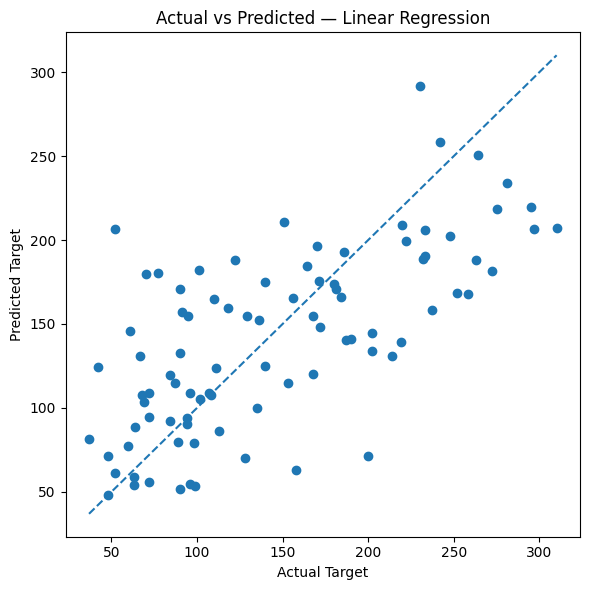

In [ ]:
best_regression_name = regression_results.iloc[0]["Model"]
best_regression_model = clone(regression_models[best_regression_name])

best_regression_model.fit(X_reg_train_full, y_reg_train_full)
regression_test_predictions = best_regression_model.predict(X_reg_test)

regression_test_results = regression_metrics(
    y_reg_test,
    regression_test_predictions
)

print("Selected regression model:", best_regression_name)
print("\nFinal test metrics:")
display(pd.DataFrame([regression_test_results]))

plt.figure(figsize=(6, 6))
plt.scatter(y_reg_test, regression_test_predictions)

minimum = min(y_reg_test.min(), regression_test_predictions.min())
maximum = max(y_reg_test.max(), regression_test_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title(f"Actual vs Predicted — {best_regression_name}")
plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.tight_layout()
plt.show()


# Part B — Binary Classification Pipeline

## 8. Load the Breast Cancer Wisconsin dataset

The target is remapped so that:

- `1 = Malignant` — positive class  
- `0 = Benign` — negative class  

This makes recall easy to interpret: malignant recall measures how many malignant cases the model successfully detects.


In [ ]:
cancer = load_breast_cancer(as_frame=True)

X_cls = cancer.data.copy()
y_cls = (cancer.target == 0).astype(int)
y_cls.name = "malignant"

classification_df = X_cls.copy()
classification_df["malignant"] = y_cls

print("Dataset shape:", classification_df.shape)
print("\nFirst five rows:")
display(classification_df.head())

print("\nClass mapping:")
print("0 = Benign")
print("1 = Malignant")


Dataset shape: (569, 31)

First five rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
0,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,1
1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,1
2,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,1
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,1
4,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,1



Class mapping:
0 = Benign
1 = Malignant


## 9. Classification data-quality checks and EDA

Missing values: 0
Duplicate rows: 0


,Class,Count
0,Benign,357
1,Malignant,212


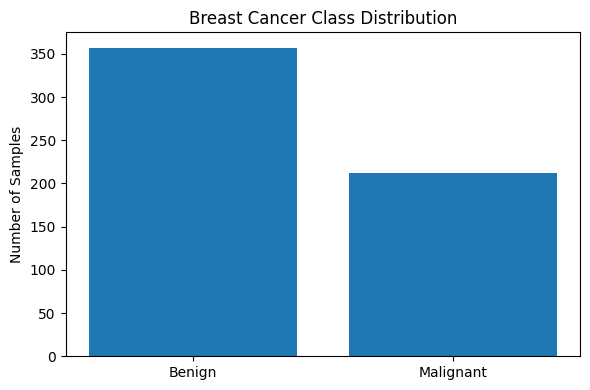


Top IQR outlier counts:


,IQR Outlier Count
area error,65
radius error,38
perimeter error,38
worst area,35
smoothness error,30
fractal dimension error,28
compactness error,28
symmetry error,27
mean area,25
worst fractal dimension,24



Decision: No missing values are present. Potential outliers are retained because they may be clinically meaningful. Standardization is applied to distance- and margin-based models.


In [ ]:
print("Missing values:", int(classification_df.isnull().sum().sum()))
print("Duplicate rows:", int(classification_df.duplicated().sum()))

class_counts = y_cls.value_counts().sort_index()
class_distribution = pd.DataFrame({
    "Class": ["Benign", "Malignant"],
    "Count": [class_counts.get(0, 0), class_counts.get(1, 0)]
})
display(class_distribution)

plt.figure(figsize=(6, 4))
plt.bar(class_distribution["Class"], class_distribution["Count"])
plt.title("Breast Cancer Class Distribution")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

print("\nTop IQR outlier counts:")
display(iqr_outlier_counts(X_cls).head(10).to_frame())

print(
    "\nDecision: No missing values are present. "
    "Potential outliers are retained because they may be clinically meaningful. "
    "Standardization is applied to distance- and margin-based models."
)


## 10. Stratified train, validation, and test split

In [ ]:
X_cls_train_full, X_cls_test, y_cls_train_full, y_cls_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_cls
)

X_cls_train, X_cls_val, y_cls_train, y_cls_val = train_test_split(
    X_cls_train_full,
    y_cls_train_full,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_cls_train_full
)

print("Training samples:", len(X_cls_train))
print("Validation samples:", len(X_cls_val))
print("Test samples:", len(X_cls_test))

print("\nMalignant proportion:")
print("Training:", y_cls_train.mean())
print("Validation:", y_cls_val.mean())
print("Test:", y_cls_test.mean())


Training samples: 341
Validation samples: 114
Test samples: 114

Malignant proportion:
Training: 0.3724340175953079
Validation: 0.37719298245614036
Test: 0.3684210526315789


## 11. Classification model comparison

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Because the positive class is **malignant**, recall is especially important: a false negative means a malignant case was incorrectly predicted as benign.


In [ ]:
classification_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            C=2,
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),
    "K-Nearest Neighbors": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=7,
            weights="distance"
        ))
    ]),
    "Naive Bayes": GaussianNB()
}

classification_rows = []

for model_name, model in classification_models.items():
    fitted_model = clone(model)
    fitted_model.fit(X_cls_train, y_cls_train)

    train_predictions = fitted_model.predict(X_cls_train)
    validation_predictions = fitted_model.predict(X_cls_val)
    validation_scores = get_positive_scores(fitted_model, X_cls_val)

    validation_results = classification_metrics(
        y_cls_val,
        validation_predictions,
        validation_scores
    )

    classification_rows.append({
        "Model": model_name,
        "Train_Accuracy": accuracy_score(y_cls_train, train_predictions),
        "Validation_Accuracy": validation_results["Accuracy"],
        "Validation_Precision": validation_results["Precision"],
        "Validation_Recall": validation_results["Recall"],
        "Validation_F1": validation_results["F1"],
        "Validation_ROC_AUC": validation_results["ROC_AUC"],
        "Accuracy_Gap": (
            accuracy_score(y_cls_train, train_predictions)
            - validation_results["Accuracy"]
        )
    })


classification_results = (
    pd.DataFrame(classification_rows)
    .sort_values(
        ["Validation_Recall", "Validation_F1", "Validation_ROC_AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(classification_results)


,Model,Train_Accuracy,Validation_Accuracy,Validation_Precision,Validation_Recall,Validation_F1,Validation_ROC_AUC,Accuracy_Gap
0,Support Vector Machine,0.9912,0.9737,0.9545,0.9767,0.9655,0.9967,0.0175
1,Logistic Regression,0.9853,0.9737,0.9545,0.9767,0.9655,0.9961,0.0117
2,Random Forest,0.9941,0.9737,0.9762,0.9535,0.9647,0.9908,0.0205
3,K-Nearest Neighbors,1.0000,0.9737,1.0000,0.9302,0.9639,0.9974,0.0263
4,Naive Bayes,0.9413,0.9561,0.9524,0.9302,0.9412,0.9912,-0.0148
5,Decision Tree,0.9648,0.8947,0.8298,0.9070,0.8667,0.9687,0.0701


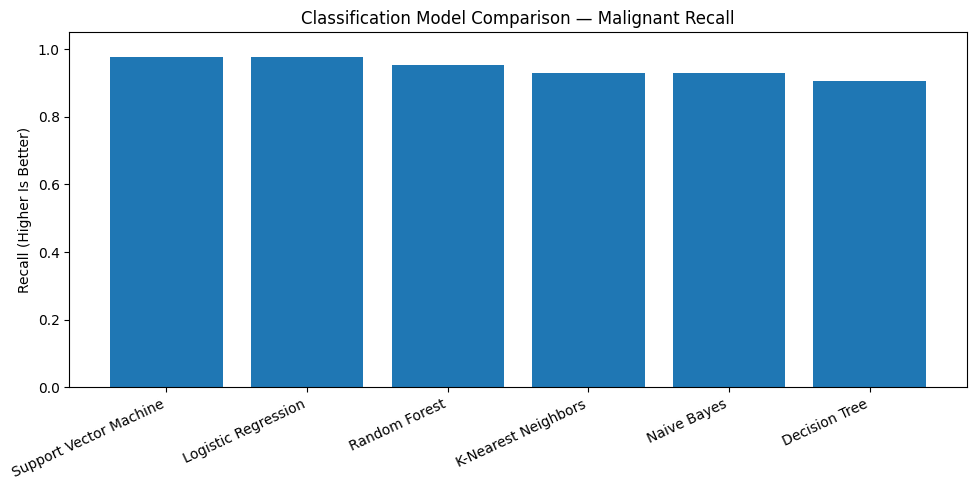

ROC-AUC values are included in the comparison table, so a separate ROC-curve graph is not required here.


In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(
    classification_results["Model"],
    classification_results["Validation_Recall"]
)
plt.title("Classification Model Comparison — Malignant Recall")
plt.ylabel("Recall (Higher Is Better)")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

print(
    "ROC-AUC values are included in the comparison table, "
    "so a separate ROC-curve graph is not required here."
)


## 12. Select and test the best classification model

Selection rule:

1. highest validation recall;
2. if tied, highest validation F1-score;
3. if still tied, highest validation ROC-AUC.

This rule prioritizes detection of malignant cases.


Selected classification model: Support Vector Machine

Final test metrics:


,Accuracy,Precision,Recall,F1,ROC_AUC
0,0.9825,1.0000,0.9524,0.9756,0.9950



Classification report:
              precision    recall  f1-score   support

      Benign     0.9730    1.0000    0.9863        72
   Malignant     1.0000    0.9524    0.9756        42

    accuracy                         0.9825       114
   macro avg     0.9865    0.9762    0.9810       114
weighted avg     0.9829    0.9825    0.9824       114



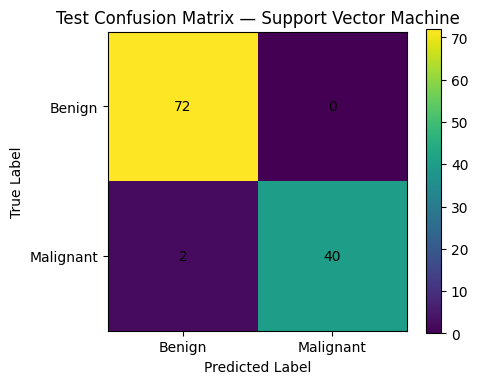

In [ ]:
best_classification_name = classification_results.iloc[0]["Model"]
best_classification_model = clone(
    classification_models[best_classification_name]
)

best_classification_model.fit(
    X_cls_train_full,
    y_cls_train_full
)

classification_test_predictions = best_classification_model.predict(
    X_cls_test
)
classification_test_scores = get_positive_scores(
    best_classification_model,
    X_cls_test
)

classification_test_results = classification_metrics(
    y_cls_test,
    classification_test_predictions,
    classification_test_scores
)

print("Selected classification model:", best_classification_name)
print("\nFinal test metrics:")
display(pd.DataFrame([classification_test_results]))

print("\nClassification report:")
print(
    classification_report(
        y_cls_test,
        classification_test_predictions,
        target_names=["Benign", "Malignant"],
        digits=4
    )
)

test_cm = confusion_matrix(
    y_cls_test,
    classification_test_predictions
)
plot_confusion_matrix(
    test_cm,
    ["Benign", "Malignant"],
    f"Test Confusion Matrix — {best_classification_name}"
)


## 13. Classification error interpretation

For the confusion matrix:

- **True Negative:** benign correctly predicted as benign;
- **False Positive:** benign incorrectly predicted as malignant;
- **False Negative:** malignant incorrectly predicted as benign;
- **True Positive:** malignant correctly predicted as malignant.

In this problem, false negatives are particularly important because they represent missed malignant cases.

> This project is an educational demonstration and is not a clinical diagnostic system.


# Part C — Clustering Pipeline

## 14. Load the Iris dataset

K-Means is trained using only the four numerical flower measurements.  
The original species labels are not used during clustering.


In [ ]:
iris = load_iris(as_frame=True)

X_cluster = iris.data.copy()
iris_labels_for_reference = iris.target.copy()

print("Dataset shape:", X_cluster.shape)
print("\nFirst five rows:")
display(X_cluster.head())

print("\nMissing values:", int(X_cluster.isnull().sum().sum()))
print("Duplicate rows:", int(X_cluster.duplicated().sum()))


Dataset shape: (150, 4)

First five rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1000,3.5000,1.4000,0.2000
1,4.9000,3.0000,1.4000,0.2000
2,4.7000,3.2000,1.3000,0.2000
3,4.6000,3.1000,1.5000,0.2000
4,5.0000,3.6000,1.4000,0.2000



Missing values: 0
Duplicate rows: 1


## 15. Clustering EDA and preprocessing

K-Means depends on distance, so the features are standardized before clustering.  
PCA is used only to create a two-dimensional visualization.


In [ ]:
display(X_cluster.describe().T)

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_cluster_pca = pca.fit_transform(X_cluster_scaled)

print(
    "Variance explained by the first two principal components:",
    f"{pca.explained_variance_ratio_.sum():.2%}"
)


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0000,5.8433,0.8281,4.3000,5.1000,5.8000,6.4000,7.9000
sepal width (cm),150.0000,3.0573,0.4359,2.0000,2.8000,3.0000,3.3000,4.4000
petal length (cm),150.0000,3.7580,1.7653,1.0000,1.6000,4.3500,5.1000,6.9000
petal width (cm),150.0000,1.1993,0.7622,0.1000,0.3000,1.3000,1.8000,2.5000


Variance explained by the first two principal components: 95.81%


## 16. Select the number of clusters

K-Means is tested with `K = 2` through `K = 6`.

- **Inertia:** lower values indicate tighter clusters, but inertia always decreases as K increases.
- **Silhouette score:** higher values indicate better separation and cohesion.

The final K is selected using the highest silhouette score.


,K,Inertia,Silhouette_Score
0,2,222.3617,0.5818
1,3,139.8205,0.4599
2,4,114.0923,0.3845
3,5,90.8076,0.3455
4,6,80.0222,0.3220


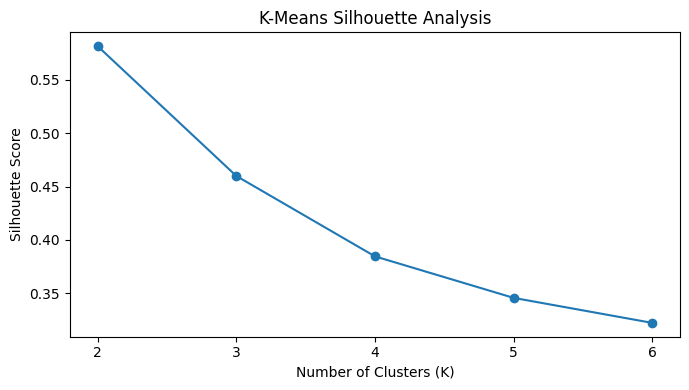

In [ ]:
kmeans_rows = []

for k in range(2, 7):
    model = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE
    )

    cluster_assignments = model.fit_predict(X_cluster_scaled)

    kmeans_rows.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette_Score": silhouette_score(
            X_cluster_scaled,
            cluster_assignments
        )
    })

kmeans_results = pd.DataFrame(kmeans_rows)
display(kmeans_results)

plt.figure(figsize=(7, 4))
plt.plot(
    kmeans_results["K"],
    kmeans_results["Silhouette_Score"],
    marker="o"
)
plt.title("K-Means Silhouette Analysis")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(kmeans_results["K"])
plt.tight_layout()
plt.show()


## 17. Final K-Means model and cluster interpretation

Selected number of clusters: 2


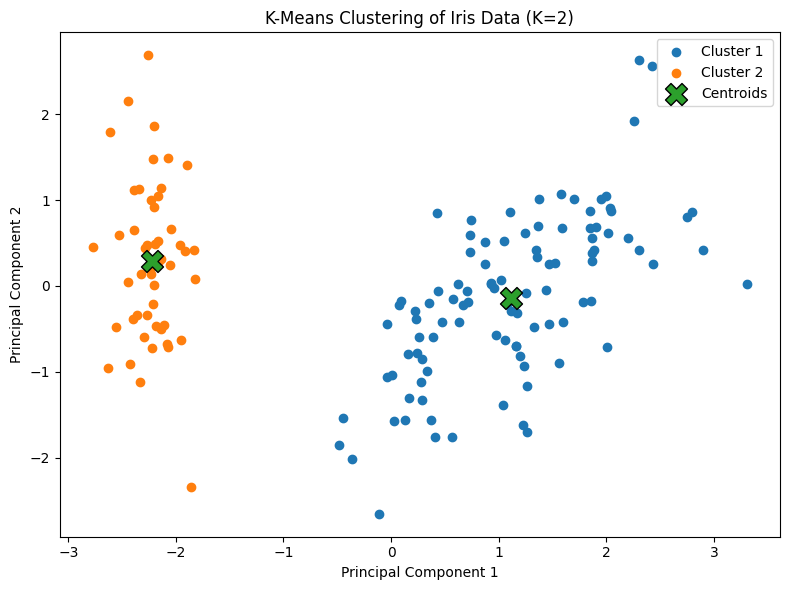

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
Cluster,,,,
1,6.2620,2.8720,4.9060,1.6760
2,5.0060,3.4280,1.4620,0.2460


In [ ]:
best_k = int(
    kmeans_results.loc[
        kmeans_results["Silhouette_Score"].idxmax(),
        "K"
    ]
)

best_kmeans = KMeans(
    n_clusters=best_k,
    n_init=20,
    random_state=RANDOM_STATE
)

final_clusters = best_kmeans.fit_predict(X_cluster_scaled)

print("Selected number of clusters:", best_k)

plt.figure(figsize=(8, 6))

for cluster_number in range(best_k):
    mask = final_clusters == cluster_number

    plt.scatter(
        X_cluster_pca[mask, 0],
        X_cluster_pca[mask, 1],
        label=f"Cluster {cluster_number + 1}"
    )

centroids_pca = pca.transform(best_kmeans.cluster_centers_)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker="X",
    s=250,
    edgecolors="black",
    label="Centroids"
)

plt.title(f"K-Means Clustering of Iris Data (K={best_k})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.tight_layout()
plt.show()

cluster_profile = (
    X_cluster.assign(Cluster=final_clusters + 1)
    .groupby("Cluster")
    .mean()
    .round(3)
)

display(cluster_profile)


# 18. Final project summary and conclusions


In [ ]:
final_summary = pd.DataFrame([
    {
        "Paradigm": "Regression",
        "Dataset": "Diabetes",
        "Selected Model": best_regression_name,
        "Selection Metric": "Lowest validation RMSE",
        "Final Test Result": (
            f"RMSE={regression_test_results['RMSE']:.4f}, "
            f"MAE={regression_test_results['MAE']:.4f}, "
            f"R2={regression_test_results['R2']:.4f}"
        )
    },
    {
        "Paradigm": "Binary Classification",
        "Dataset": "Breast Cancer Wisconsin",
        "Selected Model": best_classification_name,
        "Selection Metric": "Recall, then F1, then ROC-AUC",
        "Final Test Result": (
            f"Recall={classification_test_results['Recall']:.4f}, "
            f"F1={classification_test_results['F1']:.4f}, "
            f"ROC-AUC={classification_test_results['ROC_AUC']:.4f}"
        )
    },
    {
        "Paradigm": "Clustering",
        "Dataset": "Iris",
        "Selected Model": f"K-Means (K={best_k})",
        "Selection Metric": "Highest silhouette score",
        "Final Test Result": (
            f"Silhouette="
            f"{kmeans_results.loc[kmeans_results['K'] == best_k, 'Silhouette_Score'].iloc[0]:.4f}"
        )
    }
])

display(final_summary)


,Paradigm,Dataset,Selected Model,Selection Metric,Final Test Result
0,Regression,Diabetes,Linear Regression,Lowest validation RMSE,"RMSE=53.8534, MAE=42.7941, R2=0.4526"
1,Binary Classification,Breast Cancer Wisconsin,Support Vector Machine,"Recall, then F1, then ROC-AUC","Recall=0.9524, F1=0.9756, ROC-AUC=0.9950"
2,Clustering,Iris,K-Means (K=2),Highest silhouette score,Silhouette=0.5818


## Main findings

- Regression models were compared using validation MAE, RMSE, and R².
- Classification models were compared using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
- Train-versus-validation results were used to check generalization.
- K-Means was evaluated using inertia and silhouette score.
